# Libraries

In [1]:
import os
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from functions import Beam
import joblib

# Run test

In [2]:
geo = {"cover [mm]": 20}

mat = {'f_ck [kPa]': 25000, 'Type of cement': 3}

load = {}

expo = {'Exposure conditions': 2}

In [3]:
beam = Beam(geo=geo, mat=mat, load=load, expo=expo)
name_best_model = r'C:\git-projetos\2024-1_victor_hugo_renata_maria\carbonation_depth\models\model_HistGradientBoosting_fold_10.pkl'
model = joblib.load(name_best_model)   
model

HistGradientBoostingRegressor(random_state=42)

In [4]:
t_cover, y = beam.carbonation_depth_at_time(model=model, times=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120, 125, 150, 180], CO2_perc=0.2, rh=70)
t_cover

27.094083944354463

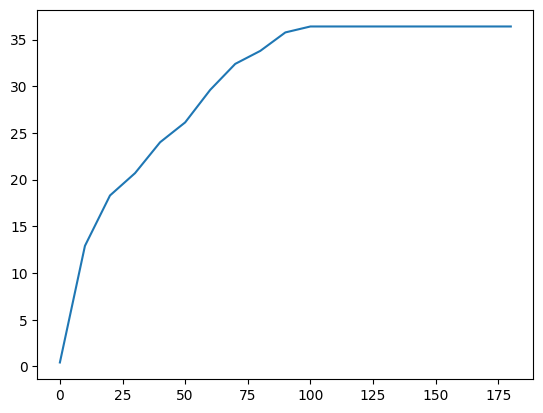

In [5]:
import matplotlib.pyplot as plt
plt.plot([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120, 125, 150, 180], y)

In [6]:
y

[0.4272951174007701,
 12.909060199676711,
 18.303281194353264,
 20.695018899962175,
 24.000692683536695,
 26.12514225269078,
 29.607062331112203,
 32.39090763963506,
 33.78180067516469,
 35.75699720798772,
 36.39404595154322,
 36.39404595154322,
 36.39404595154322,
 36.39404595154322,
 36.39404595154322]

In [7]:
import numpy as np

# Pontos conhecidos
x_conhecido = [0.4272951174007701,
 12.909060199676711,
 18.303281194353264,
 20.695018899962175,
 24.000692683536695,
 26.12514225269078,
 29.607062331112203,
 32.39090763963506,
 33.78180067516469,
 35.75699720798772,
 36.39404595154322]
y_conhecido = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# Ponto onde quer interpolar
x_novo = 38

# Interpolação linear
y_interpolado = np.interp(x_novo, x_conhecido, y_conhecido)
print(f"Para x={x_novo}, y={y_interpolado}", type(y_interpolado))  # y=5.0

Para x=38, y=100.0 <class 'numpy.float64'>


In [8]:
float(y_interpolado)

100.0